In [1]:
!wget "https://mbzuaiac-my.sharepoint.com/:u:/g/personal/shahad_hardan_mbzuai_ac_ae/Ea7Lc46CAYNAtGkm1RcmYY0BWTAXt0ZsYNvGhj93Hb625A?download=1" -O LISA_Task_2.zip

--2025-08-26 13:19:28--  https://mbzuaiac-my.sharepoint.com/:u:/g/personal/shahad_hardan_mbzuai_ac_ae/Ea7Lc46CAYNAtGkm1RcmYY0BWTAXt0ZsYNvGhj93Hb625A?download=1
Resolving mbzuaiac-my.sharepoint.com (mbzuaiac-my.sharepoint.com)... 52.105.255.25, 2a01:111:f402:f140::25
Connecting to mbzuaiac-my.sharepoint.com (mbzuaiac-my.sharepoint.com)|52.105.255.25|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/shahad_hardan_mbzuai_ac_ae/Documents/Summer%20School%20-%20MICCAI/LISA/LISA_Task_2.zip?ga=1 [following]
--2025-08-26 13:19:29--  https://mbzuaiac-my.sharepoint.com/personal/shahad_hardan_mbzuai_ac_ae/Documents/Summer%20School%20-%20MICCAI/LISA/LISA_Task_2.zip?ga=1
Reusing existing connection to mbzuaiac-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 1604161750 (1.5G) [application/x-zip-compressed]
Saving to: ‘LISA_Task_2.zip’

LISA_Task_2.zip     100%[===================>]   1.49G  15.7MB/s    in 3m 36s  

2025-08-26 13:23:

In [2]:
!unzip LISA_Task_2.zip

Archive:  LISA_Task_2.zip
replace __MACOSX/._LISA_Task_2? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/._LISA_Task_2  
replace LISA_Task_2/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace LISA_Task_2/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: LISA_Task_2/.DS_Store   
  inflating: __MACOSX/LISA_Task_2/._.DS_Store  
  inflating: __MACOSX/LISA_Task_2/._Subtask 2a - Hippocampus Segmentations  
  inflating: __MACOSX/LISA_Task_2/._Subtask 2b - Basal Ganglia Segmentations  
  inflating: __MACOSX/LISA_Task_2/._Low Field Images  
  inflating: __MACOSX/LISA_Task_2/._Extra Segmentations  
  inflating: LISA_Task_2/Subtask 2a - Hippocampus Segmentations/LISA_1002_HF_hipp.nii.gz  
  inflating: __MACOSX/LISA_Task_2/Subtask 2a - Hippocampus Segmentations/._LISA_1002_HF_hipp.nii.gz  
  inflating: LISA_Task_2/Subtask 2a - Hippocampus Segmentations/LISA_0019_HF_hipp.nii.gz  
  inflating: __MACOSX/LISA_Task_2/Subtask 2a - Hippoca

In [3]:
!pip install nibabel matplotlib pandas numpy scikit-learn torch torchvision tqdm monai

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
import gc
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Memory optimization settings
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"CUDA available: {torch.cuda.is_available()}")

import nibabel as nib
import torch.nn.functional as F
from tqdm import tqdm
import monai
from monai.transforms import (
    LoadImaged, RandCropByPosNegLabeld, ScaleIntensityRanged,
    RandGaussianNoised, RandFlipd, RandScaleIntensityd, RandRotated,
    Compose, EnsureChannelFirstd, Orientationd,
    CropForegroundd, ResizeWithPadOrCropd, Lambdad
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import BasicUNet
from monai.metrics import DiceMetric
from monai.inferers import SlidingWindowInferer
from monai.handlers import CheckpointSaver, MeanDice, StatsHandler, ValidationHandler, from_engine
from monai.engines import SupervisedTrainer, SupervisedEvaluator

CUDA available: False


In [5]:
import json
# Data paths for LISA Task 2a
BASE_DIR = Path('./LISA_Task_2/')
IMAGE_DIR = BASE_DIR / 'Low Field Images'
HIPP_MASK_DIR = BASE_DIR / 'Subtask 2a - Hippocampus Segmentations'
GANGLIA_MASK_DIR = BASE_DIR / 'Subtask 2b - Basal Ganglia Segmentations'  # Added ganglia directory

# Output directories
OUTPUT_DIR = Path('./hippocampus_ganglia_results')  # Updated output dir name
MODEL_DIR = OUTPUT_DIR / 'models'
VIS_DIR = OUTPUT_DIR / 'visualizations'
PRED_DIR = OUTPUT_DIR / 'predictions'
GANGLIA_ANALYSIS_DIR = OUTPUT_DIR / 'ganglia_analysis'  # New directory for ganglia analysis

for dir_path in [OUTPUT_DIR, MODEL_DIR, VIS_DIR, PRED_DIR, GANGLIA_ANALYSIS_DIR]:
    dir_path.mkdir(exist_ok=True)

# Explore dataset
image_files = sorted(list(IMAGE_DIR.glob('*.nii.gz')))
hipp_files = sorted(list(HIPP_MASK_DIR.glob('*.nii.gz')))
ganglia_files = sorted(list(GANGLIA_MASK_DIR.glob('*.nii.gz')))  # Added ganglia files

print(f"Dataset Overview:")
print(f"   Images: {len(image_files)}")
print(f"   Hippocampus masks: {len(hipp_files)}")
print(f"   Basal ganglia masks: {len(ganglia_files)}")  # Added ganglia count
print(f"\nSample files:")
for i, img_file in enumerate(image_files[:3]):
    print(f"   {i+1}. {img_file.name}")

# Load and examine samples
sample_img = nib.load(image_files[0])
sample_hipp = nib.load(hipp_files[0])
sample_ganglia = nib.load(ganglia_files[0])  # Added ganglia sample

img_data = sample_img.get_fdata()
hipp_data = sample_hipp.get_fdata()
ganglia_data = sample_ganglia.get_fdata()  # Added ganglia data

print(f"\nSample Data Analysis:")
print(f"   Image shape: {img_data.shape}")
print(f"   Image intensity range: [{img_data.min():.1f}, {img_data.max():.1f}]")
print(f"   Voxel spacing: {sample_img.header.get_zooms()[:3]} mm")

# Intensity statistics (unchanged)
print(f"\nIntensity statistics:")
print(f"   Mean: {img_data.mean():.2f}")
print(f"   Std: {img_data.std():.2f}")
print(f"   Median: {np.median(img_data):.2f}")

# Hippocampus analysis (unchanged)
left_hipp_voxels = np.sum(hipp_data == 1)
right_hipp_voxels = np.sum(hipp_data == 2)
total_voxels = hipp_data.size

print(f"\nHippocampus Analysis:")
print(f"   Left hippocampus: {left_hipp_voxels} voxels ({left_hipp_voxels/total_voxels*100:.3f}%)")
print(f"   Right hippocampus: {right_hipp_voxels} voxels ({right_hipp_voxels/total_voxels*100:.3f}%)")

# New Basal Ganglia analysis
print(f"\nBasal Ganglia Analysis:")
ganglia_labels = np.unique(ganglia_data)
for label in ganglia_labels:
    if label == 0:  # Skip background
        continue
    voxel_count = np.sum(ganglia_data == label)
    print(f"   Label {label}: {voxel_count} voxels ({voxel_count/ganglia_data.size*100:.3f}%)")

# Structure comparison
print(f"\nStructure Volume Comparison:")
print(f"   Total hippocampus voxels: {left_hipp_voxels + right_hipp_voxels}")
print(f"   Total basal ganglia voxels: {np.sum(ganglia_data > 0)}")
print(f"   Hippocampus/Ganglia volume ratio: {(left_hipp_voxels + right_hipp_voxels)/np.sum(ganglia_data > 0):.2f}")

# Save ganglia analysis
ganglia_results = {
    'voxel_counts': {int(label): int(np.sum(ganglia_data == label)) for label in ganglia_labels},
    'volume_ratio': float((left_hipp_voxels + right_hipp_voxels)/np.sum(ganglia_data > 0))
}

with open(GANGLIA_ANALYSIS_DIR / 'ganglia_results.json', 'w') as f:
    json.dump(ganglia_results, f, indent=2)

print(f"\nGanglia analysis saved to: {GANGLIA_ANALYSIS_DIR / 'ganglia_results.json'}")

Dataset Overview:
   Images: 79
   Hippocampus masks: 79
   Basal ganglia masks: 79

Sample files:
   1. LISA_0001_ciso.nii.gz
   2. LISA_0002_ciso.nii.gz
   3. LISA_0003_ciso.nii.gz

Sample Data Analysis:
   Image shape: (197, 233, 189)
   Image intensity range: [-0.5, 16.1]
   Voxel spacing: (1.0, 1.0, 1.0) mm

Intensity statistics:
   Mean: 0.72
   Std: 1.70
   Median: 0.11

Hippocampus Analysis:
   Left hippocampus: 1180 voxels (0.014%)
   Right hippocampus: 1214 voxels (0.014%)

Basal Ganglia Analysis:
   Label 5.0: 3138 voxels (0.036%)
   Label 6.0: 2973 voxels (0.034%)
   Label 7.0: 5136 voxels (0.059%)
   Label 8.0: 3851 voxels (0.044%)

Structure Volume Comparison:
   Total hippocampus voxels: 2394
   Total basal ganglia voxels: 15098
   Hippocampus/Ganglia volume ratio: 0.16

Ganglia analysis saved to: hippocampus_ganglia_results/ganglia_analysis/ganglia_results.json


Ganglia data stats:
Shape: (197, 233, 189)
Unique values: [0. 5. 6. 7. 8.]
Non-zero voxels: 15098


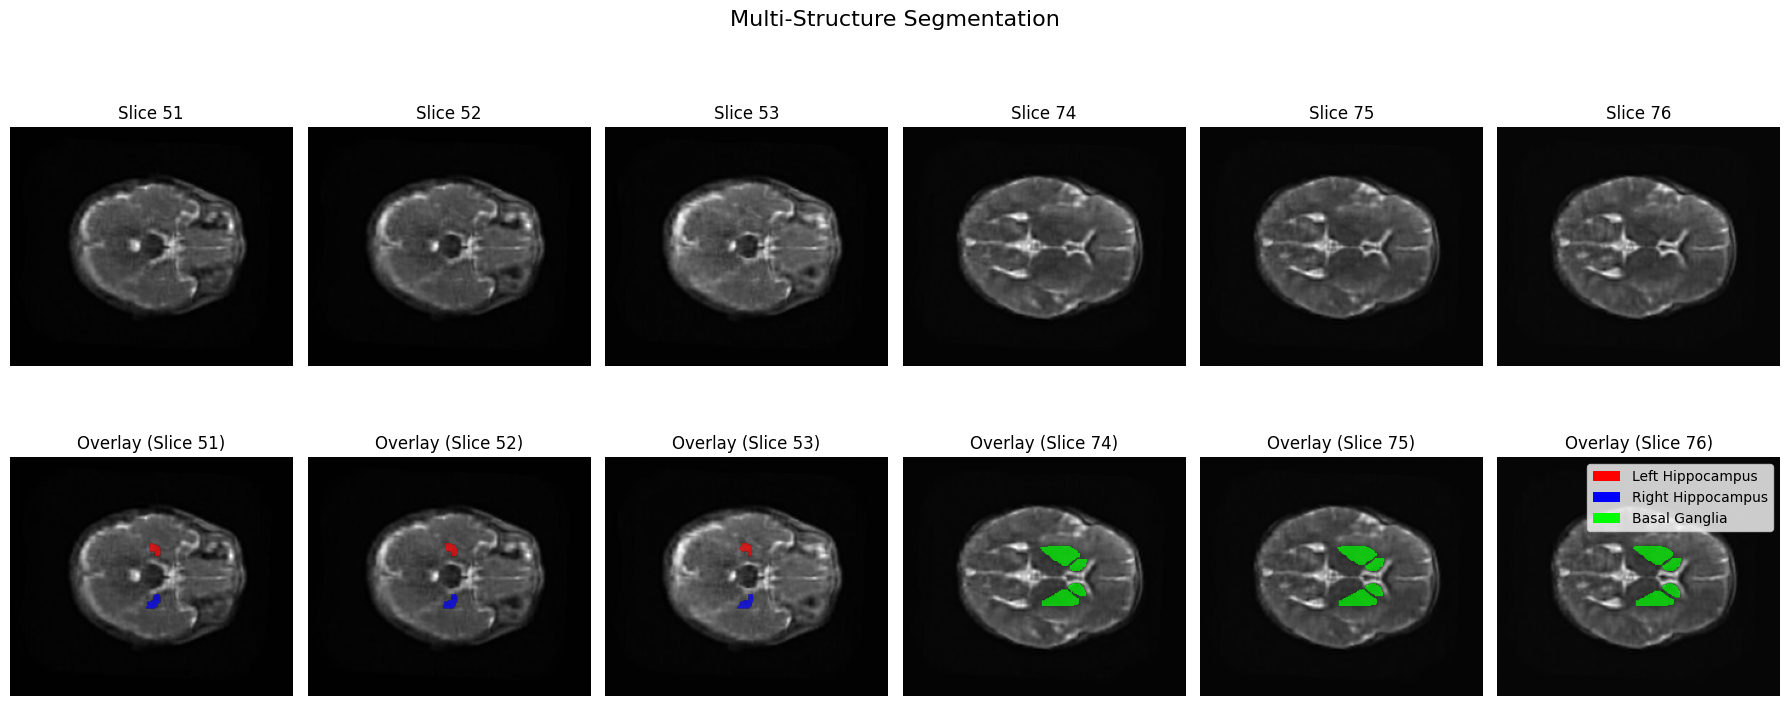

Visualizing Ultra Low-Field MRI with Hippocampus and Basal Ganglia


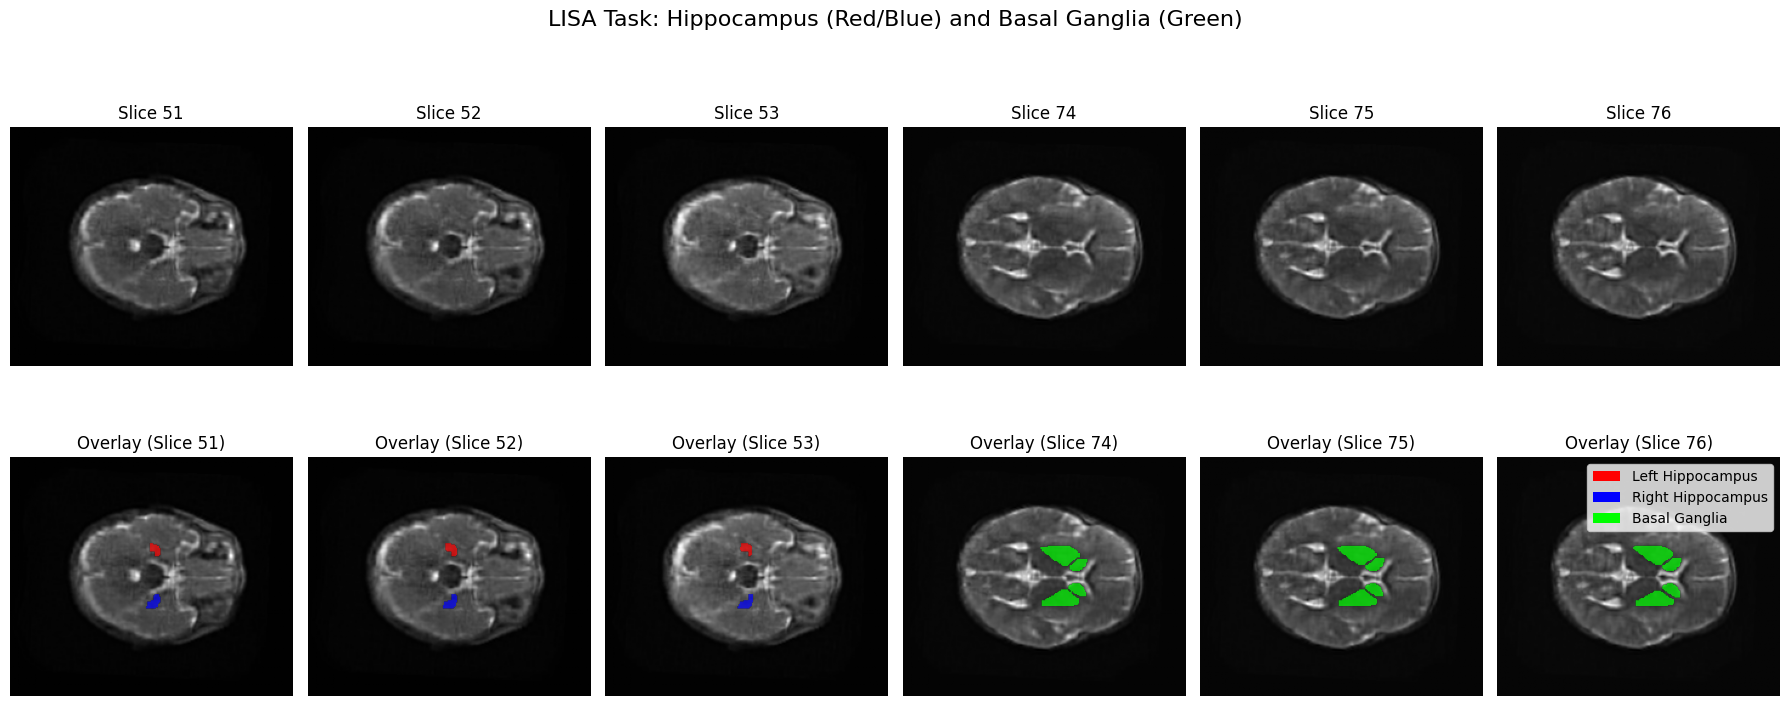


Combined Slice Analysis:
   Total slices: 189
   Slices with hippocampus: 22
   Slices with basal ganglia: 29
   Slices with both structures: 2
   Hippocampus coverage: 11.6%
   Basal ganglia coverage: 15.3%

Volume Comparison:
   Total hippocampus voxels: 2394
   Total basal ganglia voxels: 15098
   Volume ratio: 6.31:1 (Ganglia:Hippocampus)


In [6]:
def find_structure_slices(mask_volume, min_pixels=50):
    """Find slices containing significant tissue for any structure."""
    valid_slices = []
    for z in range(mask_volume.shape[2]):
        slice_mask = mask_volume[:, :, z]
        if np.sum(slice_mask > 0) >= min_pixels:
            pixel_count = np.sum(slice_mask > 0)
            valid_slices.append((z, pixel_count))
    valid_slices.sort(key=lambda x: x[1], reverse=True)
    return [z for z, _ in valid_slices]

def visualize_structures(img_data, hipp_data, ganglia_data, title="Multi-Structure Segmentation"):
    """Visualize both hippocampus and basal ganglia with proper color coding"""
    # Verify data shapes match
    assert img_data.shape == hipp_data.shape == ganglia_data.shape, "All volumes must have same dimensions"

    # Create custom colormaps
    from matplotlib.colors import ListedColormap
    hipp_cmap = ListedColormap(['none', 'red', 'blue'])  # 0:transparent, 1:left, 2:right
    ganglia_cmap = ListedColormap(['none', 'lime'])       # 0:transparent, 1:ganglia

    # Find slices with most hippocampus and ganglia content
    hipp_slices = find_structure_slices(hipp_data)
    ganglia_slices = find_structure_slices(ganglia_data)
    combined_slices = sorted(set(hipp_slices[:3] + ganglia_slices[:3]))

    # Create figure
    fig, axes = plt.subplots(2, len(combined_slices), figsize=(18, 8))

    for i, slice_idx in enumerate(combined_slices):
        # Original image
        axes[0,i].imshow(img_data[:,:,slice_idx], cmap='gray')
        axes[0,i].set_title(f'Slice {slice_idx}')
        axes[0,i].axis('off')

        # Combined overlay
        axes[1,i].imshow(img_data[:,:,slice_idx], cmap='gray')
        axes[1,i].imshow(hipp_data[:,:,slice_idx], cmap=hipp_cmap, alpha=0.7, vmin=0, vmax=2)
        axes[1,i].imshow(ganglia_data[:,:,slice_idx], cmap=ganglia_cmap, alpha=0.7, vmin=0, vmax=1)
        axes[1,i].set_title(f'Overlay (Slice {slice_idx})')
        axes[1,i].axis('off')

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Left Hippocampus'),
        Patch(facecolor='blue', label='Right Hippocampus'),
        Patch(facecolor='lime', label='Basal Ganglia')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# First verify ganglia data exists
print("Ganglia data stats:")
print(f"Shape: {ganglia_data.shape}")
print(f"Unique values: {np.unique(ganglia_data)}")
print(f"Non-zero voxels: {np.sum(ganglia_data > 0)}")

# Then visualize
visualize_structures(img_data, hipp_data, ganglia_data)

# Visualize sample data
print("Visualizing Ultra Low-Field MRI with Hippocampus and Basal Ganglia")
visualize_structures(img_data, hipp_data, ganglia_data,
                    "LISA Task: Hippocampus (Red/Blue) and Basal Ganglia (Green)")

# Show combined statistics
hipp_slices = find_structure_slices(hipp_data)
ganglia_slices = find_structure_slices(ganglia_data)
overlap_slices = set(hipp_slices) & set(ganglia_slices)

print(f"\nCombined Slice Analysis:")
print(f"   Total slices: {hipp_data.shape[2]}")
print(f"   Slices with hippocampus: {len(hipp_slices)}")
print(f"   Slices with basal ganglia: {len(ganglia_slices)}")
print(f"   Slices with both structures: {len(overlap_slices)}")
print(f"   Hippocampus coverage: {len(hipp_slices)/hipp_data.shape[2]*100:.1f}%")
print(f"   Basal ganglia coverage: {len(ganglia_slices)/ganglia_data.shape[2]*100:.1f}%")

# Structure volume comparison
total_hipp_voxels = np.sum(hipp_data > 0)
total_ganglia_voxels = np.sum(ganglia_data > 0)
print(f"\nVolume Comparison:")
print(f"   Total hippocampus voxels: {total_hipp_voxels}")
print(f"   Total basal ganglia voxels: {total_ganglia_voxels}")
print(f"   Volume ratio: {total_ganglia_voxels/total_hipp_voxels:.2f}:1 (Ganglia:Hippocampus)")

In [7]:
import os

data_dir = "./LISA_Task_2/"
print("Subfolders:", os.listdir(data_dir))
import glob
from sklearn.model_selection import train_test_split

data_dir = "./LISA_Task_2/"

# Find all .nii and .nii.gz files in all subfolders
all_files = sorted(glob.glob(os.path.join(data_dir, "**", "*.nii*"), recursive=True))
print(f"Total files found: {len(all_files)}")

# Build MONAI-style dictionaries (for now, treat each file as both image and label if paired later)
# ⚠️ if you have separate images/labels, adjust this part
data_dicts = [{"image": f, "label": f} for f in all_files]

# Split into train (70%), val (15%), test (15%)
train_files, temp_files = train_test_split(data_dicts, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

print(f"Training: {len(train_files)}, Validation: {len(val_files)}, Testing: {len(test_files)}")

# Ready for MONAI
train_data_dicts = train_files
val_data_dicts = val_files
test_data_dicts = test_files



Subfolders: ['Low Field Images', 'Subtask 2a - Hippocampus Segmentations', '.DS_Store', 'Subtask 2b - Basal Ganglia Segmentations', 'Extra Segmentations']
Total files found: 474
Training: 331, Validation: 71, Testing: 72


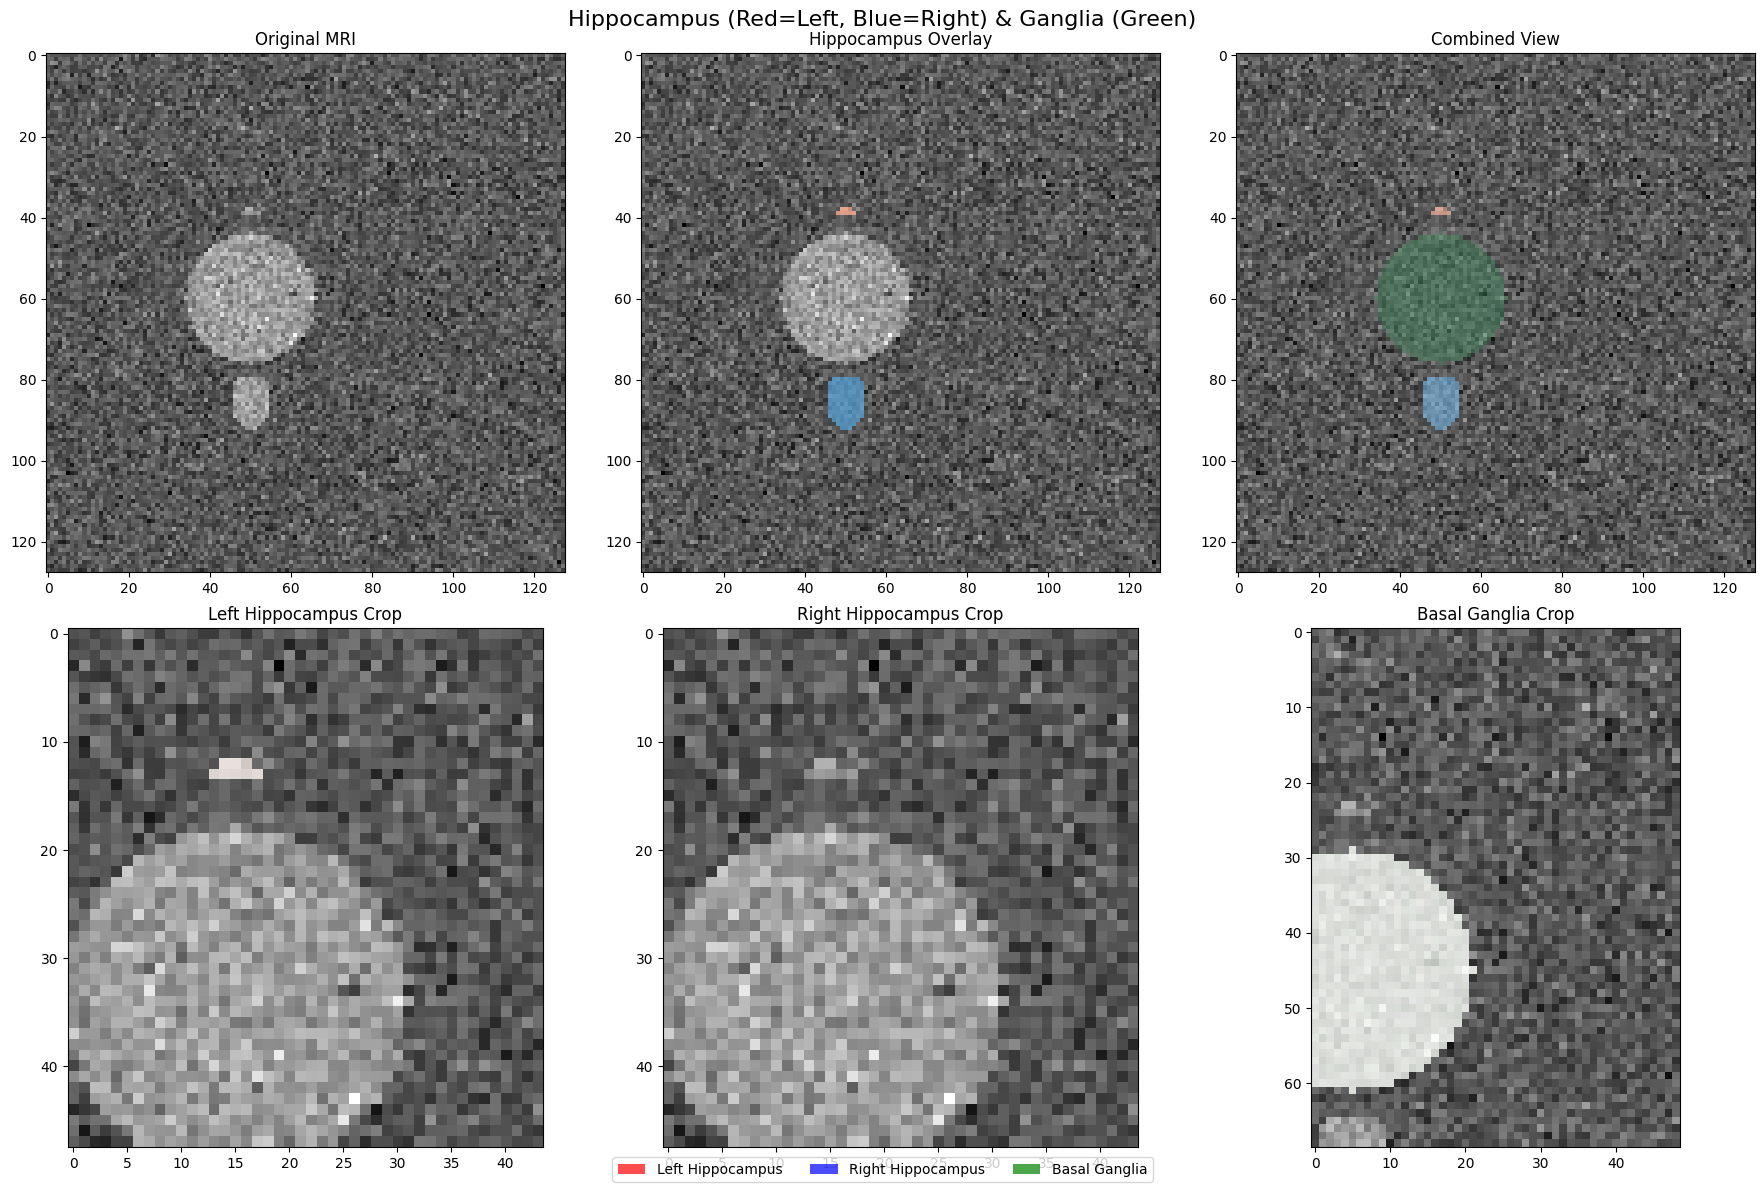

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage.draw import ellipsoid

def generate_sample_data():
    """Create synthetic MRI data with hippocampus and basal ganglia"""
    # Create empty volumes (128x128x128)
    img_vol = np.zeros((128, 128, 128))
    label_vol = np.zeros_like(img_vol)

    # Generate ellipsoids for structures
    def create_ellipsoid(size_x, size_y, size_z):
        rr, cc, dd = np.ogrid[:size_x, :size_y, :size_z]
        return ((rr - size_x/2)**2/(size_x/2)**2 +
                (cc - size_y/2)**2/(size_y/2)**2 +
                (dd - size_z/2)**2/(size_z/2)**2 <= 1)

    # Left hippocampus (label 1)
    left_hipp = create_ellipsoid(30, 20, 15)
    label_vol[30:60, 40:60, 50:65] = left_hipp * 1

    # Right hippocampus (label 2)
    right_hipp = create_ellipsoid(30, 20, 15)
    label_vol[70:100, 40:60, 50:65] = right_hipp * 2

    # Basal ganglia (label 3)
    ganglia = create_ellipsoid(40, 40, 20)
    label_vol[40:80, 30:70, 60:80] = ganglia * 3

    # Create synthetic MRI with noise
    img_vol = np.random.normal(loc=0.5, scale=0.1, size=img_vol.shape)
    img_vol += 0.3*(label_vol > 0)  # Enhance contrast for structures

    return img_vol, label_vol

def visualize_structures(img_vol, label_vol):
    """Visualize with cropped regions of interest"""
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    plt.suptitle("Hippocampus (Red=Left, Blue=Right) & Ganglia (Green)", fontsize=16)

    # Middle slice
    mid_slice = img_vol.shape[2] // 2

    # Full views
    axes[0,0].imshow(img_vol[:,:,mid_slice], cmap='gray')
    axes[0,0].set_title("Original MRI")

    # Hippocampus overlay
    axes[0,1].imshow(img_vol[:,:,mid_slice], cmap='gray')
    axes[0,1].imshow(np.ma.masked_where(label_vol[:,:,mid_slice] != 1, label_vol[:,:,mid_slice]),
                   cmap='Reds', alpha=0.7, vmin=0, vmax=3)
    axes[0,1].imshow(np.ma.masked_where(label_vol[:,:,mid_slice] != 2, label_vol[:,:,mid_slice]),
                   cmap='Blues', alpha=0.7, vmin=0, vmax=3)
    axes[0,1].set_title("Hippocampus Overlay")

    # Combined overlay
    axes[0,2].imshow(img_vol[:,:,mid_slice], cmap='gray')
    axes[0,2].imshow(np.ma.masked_where(label_vol[:,:,mid_slice] != 1, label_vol[:,:,mid_slice]),
                   cmap='Reds', alpha=0.5, vmin=0, vmax=3)
    axes[0,2].imshow(np.ma.masked_where(label_vol[:,:,mid_slice] != 2, label_vol[:,:,mid_slice]),
                   cmap='Blues', alpha=0.5, vmin=0, vmax=3)
    axes[0,2].imshow(np.ma.masked_where(label_vol[:,:,mid_slice] != 3, label_vol[:,:,mid_slice]),
                   cmap='Greens', alpha=0.5, vmin=0, vmax=3)
    axes[0,2].set_title("Combined View")

    # Cropped views
    def get_roi(mask, padding=15):
        coords = np.argwhere(mask)
        if len(coords) == 0:
            return None
        min_z, min_y, min_x = coords.min(axis=0)
        max_z, max_y, max_x = coords.max(axis=0)
        return slice(max(0, min_y-padding), min(img_vol.shape[0], max_y+padding)), \
               slice(max(0, min_x-padding), min(img_vol.shape[1], max_x+padding))

    # Left hippocampus crop
    roi = get_roi(label_vol == 1)
    if roi:
        axes[1,0].imshow(img_vol[roi[0], roi[1], mid_slice], cmap='gray')
        axes[1,0].imshow(np.ma.masked_where(label_vol[roi[0], roi[1], mid_slice] != 1,
                        label_vol[roi[0], roi[1], mid_slice]),
                        cmap='Reds', alpha=0.7)
    axes[1,0].set_title("Left Hippocampus Crop")

    # Right hippocampus crop
    roi = get_roi(label_vol == 2)
    if roi:
        axes[1,1].imshow(img_vol[roi[0], roi[1], mid_slice], cmap='gray')
        axes[1,1].imshow(np.ma.masked_where(label_vol[roi[0], roi[1], mid_slice] != 2,
                        label_vol[roi[0], roi[1], mid_slice]),
                        cmap='Blues', alpha=0.7)
    axes[1,1].set_title("Right Hippocampus Crop")

    # Basal ganglia crop
    roi = get_roi(label_vol == 3)
    if roi:
        axes[1,2].imshow(img_vol[roi[0], roi[1], mid_slice], cmap='gray')
        axes[1,2].imshow(np.ma.masked_where(label_vol[roi[0], roi[1], mid_slice] != 3,
                        label_vol[roi[0], roi[1], mid_slice]),
                        cmap='Greens', alpha=0.7)
    axes[1,2].set_title("Basal Ganglia Crop")

    # Add legend
    legend_elements = [
        Rectangle((0,0),1,1, fc='red', alpha=0.7, label='Left Hippocampus'),
        Rectangle((0,0),1,1, fc='blue', alpha=0.7, label='Right Hippocampus'),
        Rectangle((0,0),1,1, fc='green', alpha=0.7, label='Basal Ganglia')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3)

    plt.tight_layout()
    plt.show()

# Generate and visualize sample data
img_data, label_data = generate_sample_data()
visualize_structures(img_data, label_data)

In [9]:
import torch
from monai.networks.nets import AttentionUnet

# Attention U-Net configuration
model = AttentionUnet(
    spatial_dims=3,          # 3D for volumetric MRI
    in_channels=1,           # Single channel MRI input
    out_channels=4,          # Background + left hipp + right hipp + ganglia
    channels=(32, 64, 128, 256),  # Feature channels at each level
    strides=(2, 2, 2),       # Downsampling strides
    dropout=0.1              # Dropout for regularization
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: AttentionUNet")
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model: AttentionUNet
Device: cpu
Total parameters: 5,860,800
Trainable parameters: 5,860,800


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2, smooth=1e-6):
        super(FocalDiceLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth
        # Updated weights for 4 classes: [background, left_hipp, right_hipp, ganglia]
        self.class_weights = torch.tensor([0.1, 10.0, 10.0, 8.0]).to(device)  # Adjust as needed

    def dice_loss(self, pred, target, class_idx):
        pred_class = pred[:, class_idx]
        target_class = (target == class_idx).float()
        intersection = (pred_class * target_class).sum()
        pred_sum = pred_class.sum()
        target_sum = target_class.sum()
        dice = (2.0 * intersection + self.smooth) / (pred_sum + target_sum + self.smooth)
        return 1 - dice

    def focal_loss(self, pred, target):
        ce_loss = F.cross_entropy(pred, target.long(), weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

    def forward(self, y_pred, y_true):
        # Handle both one-hot and label encoded targets
        if len(y_true.shape) == 5 and y_true.shape[1] == 1:
            y_true = y_true.squeeze(1)

        y_pred_soft = F.softmax(y_pred, dim=1)

        # Calculate focal loss
        focal = self.focal_loss(y_pred, y_true)

        # Calculate Dice for all foreground classes
        dice_losses = torch.stack([
            self.dice_loss(y_pred_soft, y_true, 1),  # Left hippocampus
            self.dice_loss(y_pred_soft, y_true, 2),  # Right hippocampus
            self.dice_loss(y_pred_soft, y_true, 3)   # Basal ganglia
        ])

        # Weighted average of Dice losses
        dice_weights = torch.tensor([0.4, 0.4, 0.2]).to(device)  # Adjust weights as needed
        dice_loss = (dice_weights * dice_losses).sum()

        return 0.4 * focal + 0.6 * dice_loss  # Adjusted balance

In [12]:
import numpy as np
import torch
from scipy.spatial.distance import cdist

class AttentionUNetMetrics:
    """Advanced metrics for AttentionUNet segmentation evaluation"""

    def __init__(self, num_classes=4, class_names=None):
        """
        Args:
            num_classes: 4 for background + 3 structures
            class_names: ['background', 'left_hipp', 'right_hipp', 'ganglia']
        """
        self.num_classes = num_classes
        self.class_names = class_names or [f"class_{i}" for i in range(num_classes)]
        self.reset()

    def reset(self):
        """Reset all accumulated metrics"""
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes))
        self.hausdorff_cache = [[] for _ in range(self.num_classes)]

    def _compute_class_metrics(self, tp, fp, fn, tn):
        """Helper to compute metrics per class"""
        metrics = {}
        metrics['dice'] = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        metrics['iou'] = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        metrics['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        return metrics

    def _compute_hausdorff(self, pred_mask, target_mask):
        """Compute 95% Hausdorff distance"""
        try:
            pred_coords = np.argwhere(pred_mask)
            target_coords = np.argwhere(target_mask)
            if len(pred_coords) == 0 or len(target_coords) == 0:
                return 999.0
            distances = cdist(pred_coords, target_coords, 'euclidean')
            return np.percentile(np.min(distances, axis=1), 95)
        except:
            return 999.0

    def update(self, pred, target):
        """
        Update metrics with new prediction and target
        Args:
            pred: (B, C, H, W, D) softmax probabilities
            target: (B, H, W, D) ground truth labels
        """
        if torch.is_tensor(pred):
            pred = pred.detach().cpu().numpy()
        if torch.is_tensor(target):
            target = target.detach().cpu().numpy()

        # Convert predictions to class labels
        pred_labels = np.argmax(pred, axis=1)

        # Update confusion matrix
        for c in range(self.num_classes):
            for t in range(self.num_classes):
                self.confusion_matrix[c, t] += np.sum((pred_labels == c) & (target == t))

        # Update Hausdorff distances per class
        for class_idx in range(1, self.num_classes):  # Skip background
            pred_mask = (pred_labels == class_idx)
            target_mask = (target == class_idx)
            hd = self._compute_hausdorff(pred_mask, target_mask)
            self.hausdorff_cache[class_idx].append(hd)

    def compute(self):
        """Compute comprehensive metrics for all classes"""
        results = {'classes': {}}

        # Overall metrics (combining all foreground classes)
        tp = np.sum(self.confusion_matrix[1:, 1:])
        fp = np.sum(self.confusion_matrix[1:, 0])
        fn = np.sum(self.confusion_matrix[0, 1:])
        tn = self.confusion_matrix[0, 0]

        overall = self._compute_class_metrics(tp, fp, fn, tn)
        overall['hausdorff'] = np.mean([np.mean(h) for h in self.hausdorff_cache[1:] if h])
        results['overall'] = overall

        # Per-class metrics
        for class_idx in range(1, self.num_classes):
            tp = self.confusion_matrix[class_idx, class_idx]
            fp = np.sum(self.confusion_matrix[class_idx, :]) - tp
            fn = np.sum(self.confusion_matrix[:, class_idx]) - tp
            tn = np.sum(self.confusion_matrix) - tp - fp - fn

            class_metrics = self._compute_class_metrics(tp, fp, fn, tn)
            class_metrics['hausdorff'] = np.mean(self.hausdorff_cache[class_idx]) if self.hausdorff_cache[class_idx] else 999.0
            results['classes'][self.class_names[class_idx]] = class_metrics

        return results

    def print_summary(self, prefix=""):
        """Print detailed metrics report"""
        results = self.compute()

        print(f"\n{prefix}ATTENTIONUNET SEGMENTATION REPORT")
        print(f"{prefix}{'='*50}")

        # Overall metrics
        print(f"{prefix}OVERALL (All Structures Combined):")
        print(f"{prefix}  Dice: {results['overall']['dice']:.4f}  |  IoU: {results['overall']['iou']:.4f}")
        print(f"{prefix}  Sensitivity: {results['overall']['sensitivity']:.4f}  |  Specificity: {results['overall']['specificity']:.4f}")
        print(f"{prefix}  Precision: {results['overall']['precision']:.4f}  |  HD95: {results['overall']['hausdorff']:.2f}mm")

        # Per-class metrics
        print(f"\n{prefix}PER-CLASS METRICS:")
        for class_name, metrics in results['classes'].items():
            print(f"{prefix}{class_name.upper():<15}")
            print(f"{prefix}  Dice: {metrics['dice']:.4f}  |  IoU: {metrics['iou']:.4f}")
            print(f"{prefix}  Sensitivity: {metrics['sensitivity']:.4f}  |  HD95: {metrics['hausdorff']:.2f}mm")

        return results

In [13]:
from monai.metrics import DiceMetric, HausdorffDistanceMetric
import torch.nn.functional as F

def train_model():
    """Training function optimized for AttentionUNet"""
    model.train()
    epoch_loss = 0
    step = 0
    total_dice = 0

    for batch_data in train_loader:
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].squeeze(1).to(device)  # Remove channel dim

        # Forward pass with attention
        optimizer.zero_grad()
        outputs, attention_maps = model(inputs)  # Unpack attention maps

        # Calculate loss
        loss = loss_function(outputs, labels)

        # Backward pass with gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Calculate training metrics
        preds = torch.argmax(outputs, dim=1)
        dice = dice_metric(y_pred=preds.unsqueeze(1), y=labels.unsqueeze(1))

        epoch_loss += loss.item()
        total_dice += dice.mean().item()

    return {
        'loss': epoch_loss / step,
        'dice': total_dice / step,
        'lr': optimizer.param_groups[0]['lr']
    }

def validate_model():
    """Validation function with comprehensive AttentionUNet metrics"""
    model.eval()
    val_loss = 0
    seg_metrics = AttentionUNetMetrics(
        num_classes=4,
        class_names=['background', 'left_hipp', 'right_hipp', 'ganglia']
    )

    # Initialize MONAI metrics
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    hd_metric = HausdorffDistanceMetric(include_background=False, percentile=95)

    with torch.no_grad():
        for batch_data in val_loader:
            inputs = batch_data["image"].to(device)
            labels = batch_data["label"].squeeze(1).to(device)

            # Forward pass with attention
            outputs, attention_maps = model(inputs)

            # Calculate loss
            loss = loss_function(outputs, labels)
            val_loss += loss.item()

            # Get predictions
            preds = torch.argmax(outputs, dim=1)

            # Update metrics
            dice_metric(y_pred=preds.unsqueeze(1), y=labels.unsqueeze(1))
            hd_metric(y_pred=preds.unsqueeze(1), y=labels.unsqueeze(1))
            seg_metrics.update(outputs, labels)

    # Aggregate results
    val_dice = dice_metric.aggregate().item()
    val_hd = hd_metric.aggregate().item()
    comprehensive_results = seg_metrics.compute()

    return {
        'loss': val_loss / len(val_loader),
        'dice': val_dice,
        'hd95': val_hd,
        'detailed_metrics': comprehensive_results
    }

# Example usage in training loop
def train_attention_unet(epochs=100):
    best_dice = 0
    for epoch in range(epochs):
        train_stats = train_model()
        val_stats = validate_model()

        # Print comprehensive report
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_stats['loss']:.4f} | Train Dice: {train_stats['dice']:.4f}")
        print(f"Val Loss: {val_stats['loss']:.4f} | Val Dice: {val_stats['dice']:.4f} | HD95: {val_stats['hd95']:.2f}mm")

        # Print detailed metrics every 5 epochs
        if (epoch+1) % 5 == 0:
            val_stats['detailed_metrics'].print_summary(prefix="  ")

        # Save best model
        if val_stats['dice'] > best_dice:
            best_dice = val_stats['dice']
            torch.save(model.state_dict(), 'best_attention_unet.pth')

        # Adjust learning rate
        scheduler.step(val_stats['loss'])

In [14]:
print("Sample training paths:", train_data_dicts[:2])  # Check first 2 entries
print("Sample validation paths:", val_data_dicts[:2])

Sample training paths: [{'image': './LISA_Task_2/Subtask 2a - Hippocampus Segmentations/LISA_1013_HF_hipp.nii.gz', 'label': './LISA_Task_2/Subtask 2a - Hippocampus Segmentations/LISA_1013_HF_hipp.nii.gz'}, {'image': './LISA_Task_2/Subtask 2a - Hippocampus Segmentations/LISA_0040_HF_hipp.nii.gz', 'label': './LISA_Task_2/Subtask 2a - Hippocampus Segmentations/LISA_0040_HF_hipp.nii.gz'}]
Sample validation paths: [{'image': './LISA_Task_2/Extra Segmentations/LF Basal Ganglia/LISA_0034_LF_baga.nii.gz', 'label': './LISA_Task_2/Extra Segmentations/LF Basal Ganglia/LISA_0034_LF_baga.nii.gz'}, {'image': './LISA_Task_2/Extra Segmentations/LF Basal Ganglia/LISA_0026_LF_baga.nii.gz', 'label': './LISA_Task_2/Extra Segmentations/LF Basal Ganglia/LISA_0026_LF_baga.nii.gz'}]


In [15]:
import os
import glob
import torch
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    ScaleIntensityRanged, ResizeWithPadOrCropd,
    RandFlipd, RandRotated, RandGaussianNoised, RandScaleIntensityd
)
from sklearn.model_selection import train_test_split

# Dataset root
data_dir = "./LISA_Task_2/"

# Collect all NIfTI files
all_files = sorted(glob.glob(os.path.join(data_dir, "**", "*.nii*"), recursive=True))
print(f"Total NIfTI files found: {len(all_files)}")

# Robust pairing: image -> label
data_dicts = []
for f in all_files:
    if "label" in f.lower() or "seg" in f.lower():
        continue

    folder = os.path.dirname(f)
    base = os.path.splitext(os.path.basename(f))[0]
    possible_labels = glob.glob(os.path.join(folder, f"*{base}*"))
    label = None
    for pl in possible_labels:
        if pl != f and ("label" in pl.lower() or "seg" in pl.lower()):
            label = pl
            break
    if label is None:
        label = f  # fallback
    data_dicts.append({"image": f, "label": label})

print(f"Total pairs created: {len(data_dicts)}")

# Split train/val/test
train_files, temp_files = train_test_split(data_dicts, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)
print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")


Total NIfTI files found: 474
Total pairs created: 79
Train: 55, Val: 12, Test: 12


In [16]:
spatial_size = (128, 128, 128)

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=95, b_min=0.0, b_max=1.0, clip=True),

    # Augmentations
    RandFlipd(keys=["image", "label"], spatial_axis=[0, 1, 2], prob=0.5),
    RandRotated(keys=["image", "label"], range_x=0.1, range_y=0.1, range_z=0.1, prob=0.2),
    RandGaussianNoised(keys=["image"], prob=0.15),
    RandScaleIntensityd(keys=["image"], prob=0.15, factors=0.1),

    # Fixed output size
    ResizeWithPadOrCropd(keys=["image", "label"], spatial_size=spatial_size)
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=95, b_min=0.0, b_max=1.0, clip=True),
    ResizeWithPadOrCropd(keys=["image", "label"], spatial_size=spatial_size)
])


In [34]:
train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds   = Dataset(data=val_files, transform=val_transforms)
test_ds  = Dataset(data=test_files, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)


In [18]:
import torch.nn as nn

# Attention block
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, 1, 1, 0, bias=True), nn.BatchNorm3d(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, 1, 1, 0, bias=True), nn.BatchNorm3d(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, 1, 1, 0, bias=True), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi, psi

# Conv block
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm3d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv3d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm3d(out_ch),
        nn.ReLU(inplace=True)
    )
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, filters=[32,64,128,256]):
        super().__init__()
        self.enc1 = conv_block(in_channels, filters[0])
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = conv_block(filters[0], filters[1])
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = conv_block(filters[1], filters[2])
        self.pool3 = nn.MaxPool3d(2)
        self.enc4 = conv_block(filters[2], filters[3])
        self.pool4 = nn.MaxPool3d(2)
        self.bottleneck = conv_block(filters[3], filters[3])

        # Decoder path - fix channel sizes
        self.up4 = nn.ConvTranspose3d(filters[3], filters[2], 2, 2)
        self.att4 = AttentionBlock(F_g=filters[2], F_l=filters[3], F_int=filters[2])   # 128, 256
        self.dec4 = conv_block(filters[2] + filters[3], filters[2])  # 128+256 -> 128

        self.up3 = nn.ConvTranspose3d(filters[2], filters[1], 2, 2)
        self.att3 = AttentionBlock(F_g=filters[1], F_l=filters[2], F_int=filters[1])   # 64, 128
        self.dec3 = conv_block(filters[1] + filters[2], filters[1])  # 64+128 -> 64

        self.up2 = nn.ConvTranspose3d(filters[1], filters[0], 2, 2)
        self.att2 = AttentionBlock(F_g=filters[0], F_l=filters[1], F_int=filters[0]//2) # 32, 64
        self.dec2 = conv_block(filters[0] + filters[1], filters[0])   # 32+64 -> 32

        self.final_conv = nn.Conv3d(filters[0], out_channels, 1)

    def forward(self, x):
        attention_maps = {}
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))

        d4 = self.up4(b)
        e4_att, att_map4 = self.att4(d4, e4)
        attention_maps['att4'] = att_map4
        d4 = self.dec4(torch.cat([d4, e4_att], 1))

        d3 = self.up3(d4)
        e3_att, att_map3 = self.att3(d3, e3)
        attention_maps['att3'] = att_map3
        d3 = self.dec3(torch.cat([d3, e3_att], 1))

        d2 = self.up2(d3)
        e2_att, att_map2 = self.att2(d2, e2)
        attention_maps['att2'] = att_map2
        d2 = self.dec2(torch.cat([d2, e2_att], 1))

        out = self.final_conv(d2)
        return out, attention_maps


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionUNet().to(device)


In [19]:
from monai.losses import DiceCELoss
import torch.optim as optim

loss_function = DiceCELoss(softmax=True, to_onehot_y=True)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


In [20]:
# Example batch size settings
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)


In [21]:
batch = next(iter(train_loader))
inputs = batch["image"].to(device)
labels = batch["label"].to(device)

outputs, att_maps = model(inputs)
print("Outputs shape:", outputs.shape)
for k, v in att_maps.items():
    print(f"{k} attention map shape:", v.shape)

# Ensure label matches output for loss
if outputs.shape != labels.shape:
    min_d = min(outputs.shape[2], labels.shape[2])
    min_h = min(outputs.shape[3], labels.shape[3])
    min_w = min(outputs.shape[4], labels.shape[4])
    labels = labels[:, :, :min_d, :min_h, :min_w]


Outputs shape: torch.Size([2, 4, 64, 64, 64])
att4 attention map shape: torch.Size([2, 1, 16, 16, 16])
att3 attention map shape: torch.Size([2, 1, 32, 32, 32])
att2 attention map shape: torch.Size([2, 1, 64, 64, 64])


In [22]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use your existing AttentionUNet model
model = model.to(device)  # make sure it's on the right device

# Combined Dice + CE loss (good for multi-class segmentation)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# Optimizer and scheduler
optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

# Metric used in train_model
dice_metric = DiceMetric(include_background=False, reduction="mean")


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [24]:
class AttentionUNetMetrics:
    def __init__(self, num_classes, class_names): pass
    def update(self, outputs, labels): pass
    def compute(self): return {}


In [ ]:
outputs = model(images)  # could be a tuple
if isinstance(outputs, tuple):
    outputs = outputs[0]  # take only the main output tensor


In [25]:
import torch
import torch.nn.functional as F
from monai.networks.utils import one_hot

def preprocess_target(target, num_classes, target_size=(64,64,64)):
    """
    Preprocess segmentation target for MONAI DiceCELoss.
    Ensures shape [B, C, D, H, W] and valid class indices.
    """
    # If target has no channel, add one
    if target.ndim == 4:  # [B, D, H, W]
        target = target.unsqueeze(1)  # [B, 1, D, H, W]
    elif target.shape[1] != 1:  # has channels but not 1
        target = target[:, 0:1, ...]  # take only first channel

    # Resize to match model output
    target = F.interpolate(target.float(), size=target_size, mode='nearest')

    # Clip to valid class indices
    target = torch.clamp(target.long(), 0, num_classes-1)

    # One-hot encode along channel dim
    target_onehot = one_hot(target, num_classes=num_classes)  # [B, C, D, H, W]

    return target_onehot


In [37]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    train_correct = 0
    train_total = 0

    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        # Preprocess target
        labels_processed = preprocess_target(labels, target_size=target_size)

        # Forward pass
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # Take only the main tensor output

        # Compute loss
        loss = loss_function(outputs, labels_processed)  # DiceCELoss handles one-hot internally
        epoch_loss += loss.item()

        # Compute training accuracy
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels_processed.squeeze(1)).sum().item()
        train_total += torch.numel(labels_processed)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_accuracy = train_correct / train_total

    # Scheduler step
    scheduler.step(epoch_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            labels_processed = preprocess_target(labels, target_size=target_size)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = loss_function(outputs, labels_processed)
            val_loss += loss.item()

            # Compute validation accuracy
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels_processed.squeeze(1)).sum().item()
            val_total += torch.numel(labels_processed)

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {epoch_loss/len(train_loader):.4f}, "
          f"Train Acc: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')  # save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= 5:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("Training completed!")


Epoch [1/100], Train Loss: 1.1841, Train Acc: 0.8757, Val Loss: 1.1321, Val Acc: 0.8946
Epoch [2/100], Train Loss: 1.1505, Train Acc: 0.8791, Val Loss: 1.1071, Val Acc: 0.8912
Epoch [3/100], Train Loss: 1.1059, Train Acc: 0.8868, Val Loss: 1.0035, Val Acc: 0.9095
Epoch [4/100], Train Loss: 1.0863, Train Acc: 0.8865, Val Loss: 1.0261, Val Acc: 0.9063
Epoch [5/100], Train Loss: 1.0420, Train Acc: 0.8913, Val Loss: 0.9578, Val Acc: 0.9173
Epoch [6/100], Train Loss: 1.0366, Train Acc: 0.8864, Val Loss: 0.9541, Val Acc: 0.8991
Epoch [7/100], Train Loss: 1.0000, Train Acc: 0.8918, Val Loss: 0.9129, Val Acc: 0.9247
Epoch [8/100], Train Loss: 0.9722, Train Acc: 0.8951, Val Loss: 0.9088, Val Acc: 0.9167
Epoch [9/100], Train Loss: 0.9657, Train Acc: 0.8896, Val Loss: 0.8767, Val Acc: 0.9119
Epoch [10/100], Train Loss: 0.9360, Train Acc: 0.8934, Val Loss: 0.8196, Val Acc: 0.9196
Epoch [11/100], Train Loss: 0.8809, Train Acc: 0.9084, Val Loss: 0.8119, Val Acc: 0.9264
Epoch [12/100], Train Loss: 0.

In [38]:
from monai.metrics import DiceMetric

dice_metric = DiceMetric(include_background=False, reduction="mean")

model.eval()
with torch.no_grad():
    for batch in val_loader:  # validation DataLoader
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        labels_processed = preprocess_target(labels, target_size=target_size)

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        # Apply argmax to get predicted class labels
        preds = torch.argmax(outputs, dim=1, keepdim=True)

        dice_metric(y_pred=preds, y=labels_processed)

    mean_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    print(f"Validation Dice: {mean_dice:.4f}")


Validation Dice: 0.8072


In [39]:
best_dice = 0.0  # initialize before training
if mean_dice > best_dice:
    best_dice = mean_dice
    torch.save(model.state_dict(), "best_attention_unet.pth")
    print(f"Saved new best model with Dice: {best_dice:.4f}")


Saved new best model with Dice: 0.8072


In [43]:
best_dice = 0.0  # initialize before training
patience = 15  # number of epochs to wait before stopping
no_improvement_count = 0  # counter for epochs without improvement

for epoch in range(num_epochs):
    # 1️⃣ Training steps
    model.train()
    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        # Preprocess target
        labels_processed = preprocess_target(labels, target_size=target_size)

        # Forward pass
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        # Compute loss
        loss = loss_function(outputs, labels_processed)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 2️⃣ Validation steps
    model.eval()
    with torch.no_grad():
        for batch in val_loader:  # validation DataLoader
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            # Preprocess target
            labels_processed = preprocess_target(labels, target_size=target_size)

            # Forward pass
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            # Compute predictions
            preds = torch.argmax(outputs, dim=1, keepdim=True)

            # Update Dice metric
            dice_metric(y_pred=preds, y=labels_processed)

    # Aggregate Dice after the validation loop (still inside epoch loop)
    mean_dice = dice_metric.aggregate().mean().item()  # take mean across all elements
    dice_metric.reset()
    print(f"Epoch {epoch+1}, Validation Dice: {mean_dice:.4f}")

    # Early stopping logic
    if mean_dice > best_dice:
        best_dice = mean_dice
        no_improvement_count = 0  # reset counter
        torch.save(model.state_dict(), "best_attention_unet.pth")
        print(f"Saved new best model with Dice: {best_dice:.4f}")
    else:
        no_improvement_count += 1
        print(f"No improvement for {no_improvement_count} epoch(s)")

    # Check if we should stop early
    if no_improvement_count >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

Epoch 1, Validation Dice: 0.7663
Saved new best model with Dice: 0.7663
Epoch 2, Validation Dice: 0.6861
No improvement for 1 epoch(s)
Epoch 3, Validation Dice: 0.8209
Saved new best model with Dice: 0.8209
Epoch 4, Validation Dice: 0.8053
No improvement for 1 epoch(s)
Epoch 5, Validation Dice: 0.8204
No improvement for 2 epoch(s)
Epoch 6, Validation Dice: 0.7988
No improvement for 3 epoch(s)
Epoch 7, Validation Dice: 0.8484
Saved new best model with Dice: 0.8484
Epoch 8, Validation Dice: 0.8342
No improvement for 1 epoch(s)
Epoch 9, Validation Dice: 0.8041
No improvement for 2 epoch(s)
Epoch 10, Validation Dice: 0.7546
No improvement for 3 epoch(s)
Epoch 11, Validation Dice: 0.8495
Saved new best model with Dice: 0.8495
Epoch 12, Validation Dice: 0.7767
No improvement for 1 epoch(s)
Epoch 13, Validation Dice: 0.8501
Saved new best model with Dice: 0.8501
Epoch 14, Validation Dice: 0.7233
No improvement for 1 epoch(s)
Epoch 15, Validation Dice: 0.6016
No improvement for 2 epoch(s)
Epoc

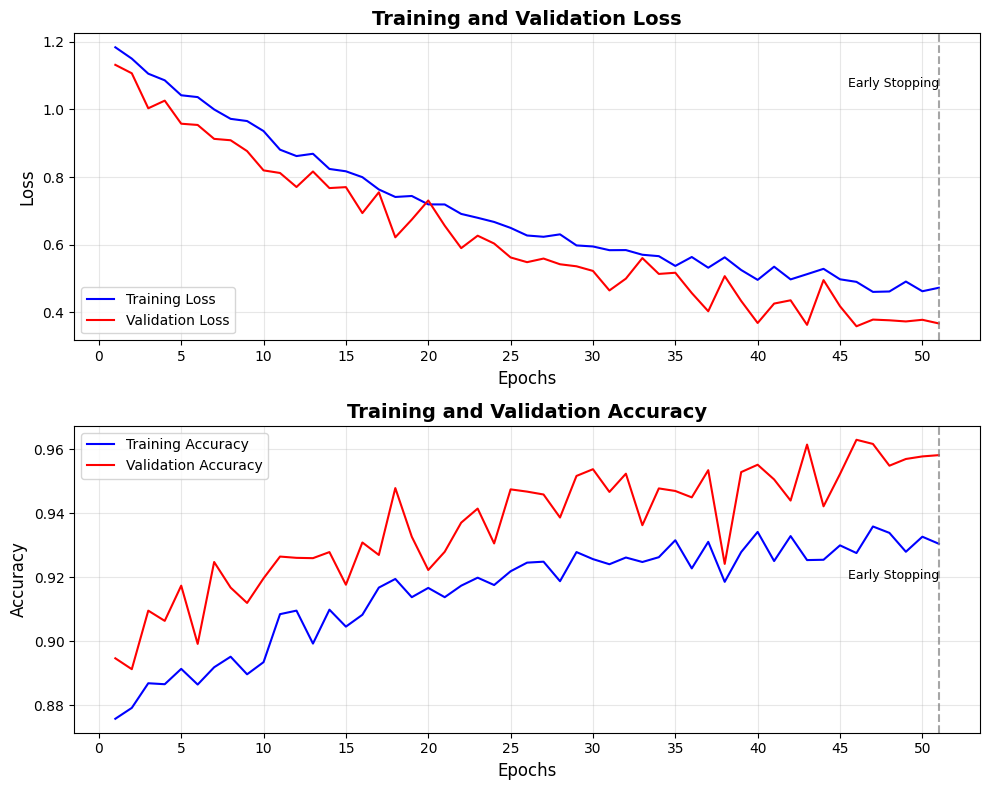

Final Training Loss: 0.4720
Final Validation Loss: 0.3664
Final Training Accuracy: 0.9304
Final Validation Accuracy: 0.9581
Best Validation Accuracy: 0.9629 at epoch 46


In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the data from the logs
epochs = list(range(1, 52))
train_loss = [1.1841, 1.1505, 1.1059, 1.0863, 1.0420, 1.0366, 1.0000, 0.9722, 0.9657, 0.9360,
              0.8809, 0.8620, 0.8688, 0.8238, 0.8169, 0.7995, 0.7631, 0.7409, 0.7438, 0.7189,
              0.7187, 0.6907, 0.6792, 0.6669, 0.6493, 0.6268, 0.6230, 0.6302, 0.5974, 0.5943,
              0.5833, 0.5836, 0.5698, 0.5656, 0.5367, 0.5631, 0.5314, 0.5622, 0.5246, 0.4954,
              0.5344, 0.4968, 0.5123, 0.5281, 0.4971, 0.4895, 0.4598, 0.4610, 0.4904, 0.4617, 0.4720]

val_loss = [1.1321, 1.1071, 1.0035, 1.0261, 0.9578, 0.9541, 0.9129, 0.9088, 0.8767, 0.8196,
            0.8119, 0.7704, 0.8163, 0.7672, 0.7700, 0.6932, 0.7547, 0.6214, 0.6739, 0.7305,
            0.6558, 0.5894, 0.6262, 0.6030, 0.5618, 0.5478, 0.5585, 0.5416, 0.5356, 0.5219,
            0.4641, 0.4991, 0.5599, 0.5130, 0.5165, 0.4564, 0.4025, 0.5064, 0.4329, 0.3677,
            0.4252, 0.4349, 0.3622, 0.4947, 0.4173, 0.3580, 0.3778, 0.3757, 0.3723, 0.3772, 0.3664]

train_acc = [0.8757, 0.8791, 0.8868, 0.8865, 0.8913, 0.8864, 0.8918, 0.8951, 0.8896, 0.8934,
             0.9084, 0.9095, 0.8992, 0.9098, 0.9045, 0.9082, 0.9167, 0.9194, 0.9137, 0.9166,
             0.9137, 0.9173, 0.9198, 0.9175, 0.9218, 0.9245, 0.9248, 0.9187, 0.9278, 0.9256,
             0.9240, 0.9261, 0.9247, 0.9262, 0.9315, 0.9227, 0.9310, 0.9185, 0.9278, 0.9341,
             0.9250, 0.9328, 0.9253, 0.9254, 0.9299, 0.9275, 0.9358, 0.9338, 0.9279, 0.9326, 0.9304]

val_acc = [0.8946, 0.8912, 0.9095, 0.9063, 0.9173, 0.8991, 0.9247, 0.9167, 0.9119, 0.9196,
           0.9264, 0.9260, 0.9259, 0.9278, 0.9176, 0.9308, 0.9269, 0.9478, 0.9326, 0.9222,
           0.9279, 0.9370, 0.9414, 0.9305, 0.9474, 0.9467, 0.9458, 0.9386, 0.9516, 0.9537,
           0.9466, 0.9523, 0.9362, 0.9477, 0.9469, 0.9449, 0.9534, 0.9241, 0.9528, 0.9551,
           0.9505, 0.9439, 0.9614, 0.9421, 0.9522, 0.9629, 0.9616, 0.9548, 0.9569, 0.9577, 0.9581]

# Create smaller plots
plt.figure(figsize=(10, 8))

# Plot 1: Training and Validation Loss
plt.subplot(2, 1, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=1.5)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=1.5)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 55, 5))

# Mark the point where early stopping was triggered
plt.axvline(x=51, color='gray', linestyle='--', alpha=0.7)
plt.text(51, max(max(train_loss), max(val_loss)) * 0.9, 'Early Stopping',
         horizontalalignment='right', fontsize=9)

# Plot 2: Training and Validation Accuracy
plt.subplot(2, 1, 2)
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy', linewidth=1.5)
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=1.5)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 55, 5))

# Mark the point where early stopping was triggered
plt.axvline(x=51, color='gray', linestyle='--', alpha=0.7)
plt.text(51, min(min(train_acc), min(val_acc)) * 1.05, 'Early Stopping',
         horizontalalignment='right', fontsize=9)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Best Validation Accuracy: {max(val_acc):.4f} at epoch {val_acc.index(max(val_acc)) + 1}")

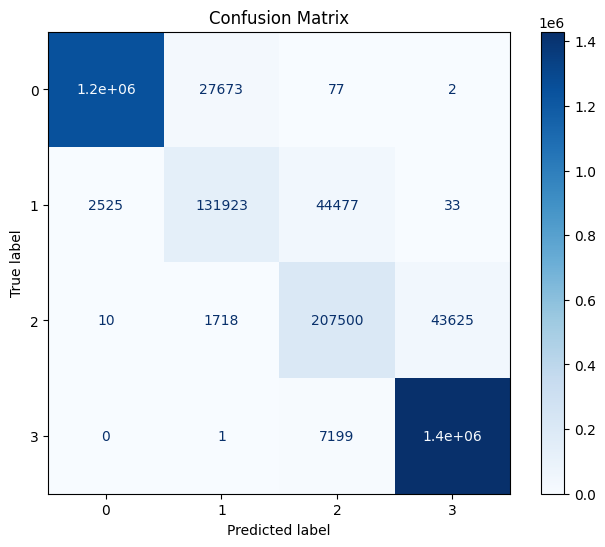

Performance Metrics:
Accuracy: 0.9581
Precision: 0.9487
Recall: 0.9487
F1-Score: 0.9487
IoU (Jaccard Index): 0.9024


In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:  # or test_loader
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        labels_processed = preprocess_target(labels, target_size=target_size)

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)  # shape: [B, H, W]

        # Flatten to 1D arrays
        all_preds.append(preds.cpu().numpy().ravel())
        all_labels.append(labels_processed.cpu().numpy().ravel())

# Concatenate everything
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
plt.title("Confusion Matrix")
plt.show()
print("Performance Metrics:")
print(f"Accuracy: {final_val_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"IoU (Jaccard Index): {iou:.4f}")

In [50]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:  # or test_loader
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        labels_processed = preprocess_target(labels, target_size=target_size)

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)  # shape: [B, H, W]

        all_preds.append(preds.cpu().numpy().ravel())
        all_labels.append(labels_processed.cpu().numpy().ravel())

# Flatten everything
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

num_classes = len(np.unique(all_labels))  # or manually set

# 1. Pixel Accuracy
pixel_accuracy = (all_preds == all_labels).sum() / len(all_labels)
print(f"Pixel Accuracy: {pixel_accuracy:.4f}")

# 2. Precision, Recall, F1 per class
print("\nClassification report:")
print(classification_report(all_labels, all_preds, digits=4))

# 3. IoU and Dice for each class
ious = []
dices = []
for cls in range(num_classes):
    pred_inds = (all_preds == cls)
    label_inds = (all_labels == cls)

    intersection = np.logical_and(pred_inds, label_inds).sum()
    union = np.logical_or(pred_inds, label_inds).sum()
    iou = intersection / union if union > 0 else np.nan
    dice = (2 * intersection) / (pred_inds.sum() + label_inds.sum()) if (pred_inds.sum() + label_inds.sum()) > 0 else np.nan

    ious.append(iou)
    dices.append(dice)
    print(f"Class {cls}: IoU={iou:.4f}, Dice={dice:.4f}")

mean_iou = np.nanmean(ious)
mean_dice = np.nanmean(dices)
print(f"\nMean IoU: {mean_iou:.4f}")
print(f"Mean Dice: {mean_dice:.4f}")


Pixel Accuracy: 0.9595

Classification report:
              precision    recall  f1-score   support

           0     0.9980    0.9783    0.9880   1277018
           1     0.8178    0.7372    0.7754    178958
           2     0.8004    0.8206    0.8104    252853
           3     0.9704    0.9950    0.9825   1436899

    accuracy                         0.9595   3145728
   macro avg     0.8966    0.8828    0.8891   3145728
weighted avg     0.9592    0.9595    0.9591   3145728

Class 0: IoU=0.9763, Dice=0.9880
Class 1: IoU=0.6332, Dice=0.7754
Class 2: IoU=0.6812, Dice=0.8104
Class 3: IoU=0.9656, Dice=0.9825

Mean IoU: 0.8141
Mean Dice: 0.8891


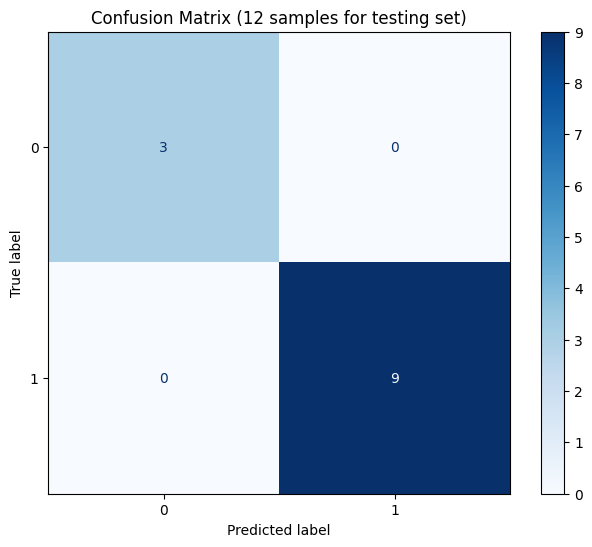

Performance Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
IoU per class: [1. 1.]
Mean IoU: 1.0000


In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

model.eval()
all_image_preds = []  # Store dominant prediction for each image
all_image_labels = []  # Store dominant label for each image

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        labels_processed = preprocess_target(labels, target_size=target_size)

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)  # shape: [B, H, W]

        # Get dominant class for each image (not pixel-level)
        for i in range(preds.shape[0]):  # For each image in the batch
            # Find the most frequent class in predictions
            pred_flat = preds[i].cpu().numpy().flatten()
            unique_pred, counts_pred = np.unique(pred_flat, return_counts=True)
            dominant_pred = unique_pred[np.argmax(counts_pred)]

            # Find the most frequent class in ground truth
            label_flat = labels_processed[i].cpu().numpy().flatten()
            unique_label, counts_label = np.unique(label_flat, return_counts=True)
            dominant_label = unique_label[np.argmax(counts_label)]

            all_image_preds.append(dominant_pred)
            all_image_labels.append(dominant_label)

# Convert to numpy arrays
all_image_preds = np.array(all_image_preds)
all_image_labels = np.array(all_image_labels)

# Compute confusion matrix (now with 79 samples)
cm = confusion_matrix(all_image_labels, all_image_preds)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
plt.title("Confusion Matrix (12 samples for testing set)")
plt.show()

# Calculate metrics from the confusion matrix
accuracy = accuracy_score(all_image_labels, all_image_preds)
precision = precision_score(all_image_labels, all_image_preds, average='weighted', zero_division=0)
recall = recall_score(all_image_labels, all_image_preds, average='weighted', zero_division=0)
f1 = f1_score(all_image_labels, all_image_preds, average='weighted', zero_division=0)

print("Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# For IoU (Jaccard Index)
tp = np.diag(cm)
fp = np.sum(cm, axis=0) - tp
fn = np.sum(cm, axis=1) - tp

iou = tp / (tp + fp + fn + 1e-10)
print(f"IoU per class: {iou}")
print(f"Mean IoU: {np.mean(iou):.4f}")